1. Installing & Importing dependencies

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 621.2 kB/s eta 0:00:17
   - -------------------------------------- 0.5/11.0 MB 621.2 kB/s eta 0:00:17
   -- ------------------------------------- 0.8/11.0 MB 599.2 kB/s eta 0:00:18
   --- ------------------------------------ 1.0/11.0 MB 680.3 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/11.0 MB 680.3 kB/s eta 0:00:15
   ---- ----------------------------------- 1.3/11.0 MB 664.5 kB/s eta 0:00:15
   ---- ----------------------------------- 1.3/11.0 MB 664.5 kB/s eta 0:00:15
   ----- ---------------------------------- 1.6/11.0 MB 699.0 kB/s eta 0:00:14
   ------ 


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

2. Dataset Overview 

In [3]:
df = pd.read_csv("udemy.csv")
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   object
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(4), object(6)
memory usage: 291.4+ KB


,course_id,num_subscribers,num_reviews,num_lectures
count,3.682000e+03,3682.000000,3682.000000,3682.000000
mean,6.766121e+05,3194.230310,156.093156,40.065182
std,3.436355e+05,9499.378361,934.957204,50.373299
min,8.324000e+03,0.000000,0.000000,0.000000
25%,4.078430e+05,110.250000,4.000000,15.000000
50%,6.885580e+05,911.500000,18.000000,25.000000
75%,9.617515e+05,2540.250000,67.000000,45.000000
max,1.282064e+06,268923.000000,27445.000000,779.000000


3. Data Cleaning

In [4]:
import pandas as pd
import numpy as np

# 1️⃣ Load the dataset
df = pd.read_csv("udemy.csv")

print("📘 Original Data Overview:")
print("~ INFO")
print(df.info())
print("--------------------------------------------------------------------------------")
print("~ HEAD")
print(df.head(), "\n")

# 2️⃣ Drop duplicates
df = df.drop_duplicates()

# 3️⃣ Clean and convert 'price' column
df['price'] = (
    df['price']
    .astype(str)
    .str.replace('Free', '0', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
)
df['price'] = pd.to_numeric(df['price'], errors='coerce')  # Convert safely to float

# 4️⃣ Convert numeric columns properly
numeric_cols = ['num_subscribers', 'num_reviews', 'num_lectures', 'content_duration']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert all to numeric safely

# 5️⃣ Convert published_timestamp to datetime
df['published_timestamp'] = pd.to_datetime(df['published_timestamp'], errors='coerce')

# 6️⃣ Handle missing values
for col in numeric_cols + ['price']:
    df[col] = df[col].fillna(df[col].median())

# Fill missing text columns with 'Unknown'
text_cols = ['course_title', 'level', 'subject']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().replace('', 'Unknown')

# 7️⃣ Standardize text formatting
df['course_title'] = df['course_title'].str.title()
df['subject'] = df['subject'].str.title()
df['level'] = df['level'].str.title()

# 8️⃣ Final verification
print("✅ Data Cleaning Completed Successfully!\n")
print("--------------------------------------------------------------------------------")
print("~ INFO")
print(df.info())
print("--------------------------------------------------------------------------------")
print("~ HEAD")
print(df.head())


📘 Original Data Overview:
~ INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   object
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(4), object(6)
memory usage: 291.4+ KB
None
--------------------------------------------------------------------------------
~ HEAD
   course_id                                       course_title  is_p

4. Visualization

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic stats
print("~ Basic Statistical Summary ~")
print("~ DESCRIBE")
print(df.describe())

print("--------------------------------------------------------------------------------------------------------------")

# Top 10 most popular courses
top_courses = df.nlargest(10, 'num_subscribers')[['course_title', 'num_subscribers']]
print("~ TOP 10 COURSES")
print(top_courses)

~ Basic Statistical Summary ~
~ DESCRIBE
          course_id        price  num_subscribers   num_reviews  num_lectures  \
count  3.676000e+03  3676.000000      3676.000000   3676.000000   3676.000000   
mean   6.765390e+05    66.063656      3187.668934    156.205114     40.096572   
std    3.434354e+05    61.014309      9483.366476    935.682615     50.407036   
min    8.324000e+03     0.000000         0.000000      0.000000      0.000000   
25%    4.079370e+05    20.000000       111.000000      4.000000     15.000000   
50%    6.881680e+05    45.000000       912.000000     18.000000     25.000000   
75%    9.616435e+05    95.000000      2544.000000     67.000000     46.000000   
max    1.282064e+06   200.000000    268923.000000  27445.000000    779.000000   

       content_duration  
count            3676.0  
mean                0.0  
std                 0.0  
min                 0.0  
25%                 0.0  
50%                 0.0  
75%                 0.0  
max                 0

~ SUBJECT DISTRIBUTION


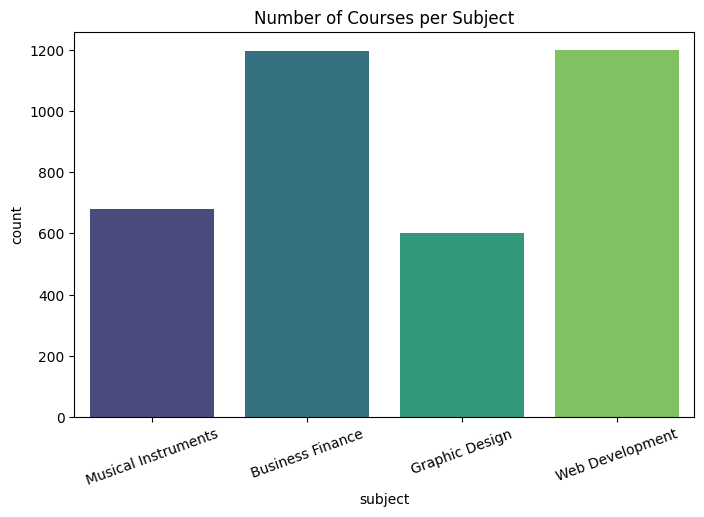

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='subject', data=df, hue='subject', palette='viridis', legend=False)
plt.title('Number of Courses per Subject')
plt.xticks(rotation=20)
print("~ SUBJECT DISTRIBUTION")
plt.show()


# # Distribution of subjects
# plt.figure(figsize=(8,5))
# sns.countplot(x='subject', data=df, palette='viridis')
# plt.title('Number of Courses per Subject')
# plt.xticks(rotation=20)
# print("~ SUBJECT DISTRIBUTION")
# plt.show()

~ CORRELATION HEATMAP


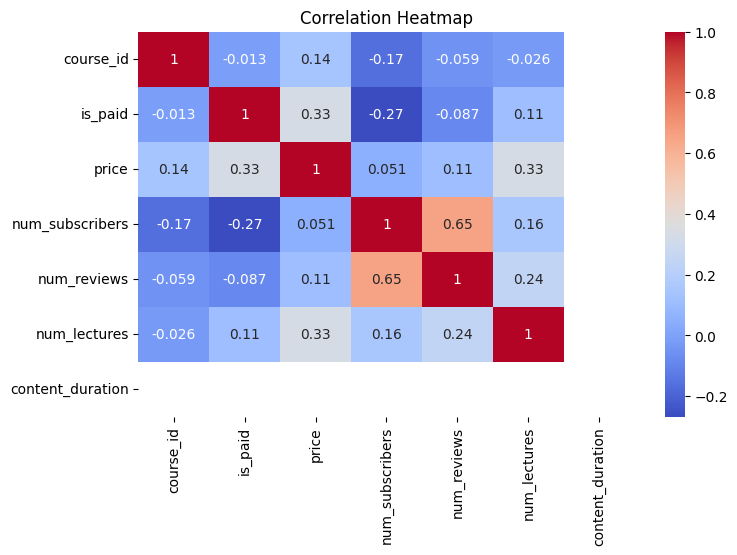

In [7]:
# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
print("~ CORRELATION HEATMAP")
plt.show()


~ SUBSCRIBERS VS REVIEWS


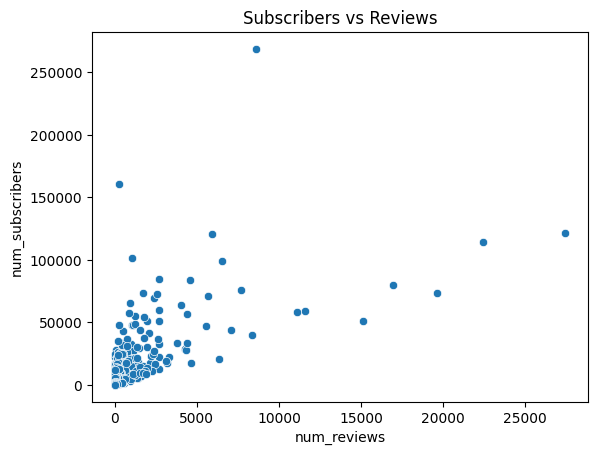

In [8]:
# Subscribers vs Reviews
sns.scatterplot(x='num_reviews', y='num_subscribers', data=df)
plt.title('Subscribers vs Reviews')
print("~ SUBSCRIBERS VS REVIEWS")
plt.show()

~ AVERAGE PRICE BY COURSE LEVEL


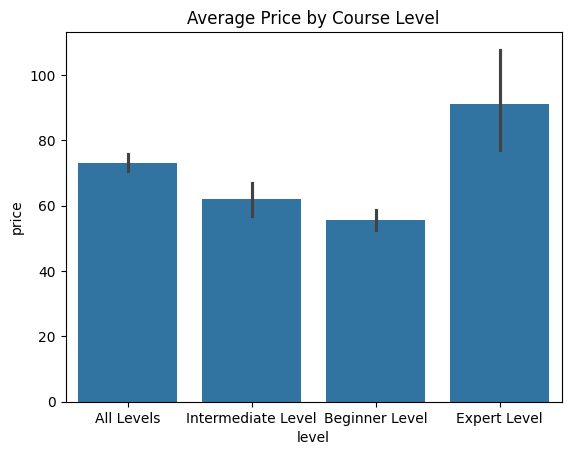

In [9]:
# Level vs Average Price
sns.barplot(x='level', y='price', data=df, estimator=np.mean)
plt.title('Average Price by Course Level')
print("~ AVERAGE PRICE BY COURSE LEVEL")
plt.show()

5. Predective Model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create target variable
median_subs = df['num_subscribers'].median()
df['is_popular'] = np.where(df['num_subscribers'] > median_subs, 1, 0)

# Encode categorical features
le = LabelEncoder()
df['level_enc'] = le.fit_transform(df['level'])
df['subject_enc'] = le.fit_transform(df['subject'])
df['is_paid_enc'] = le.fit_transform(df['is_paid'])

# Select features
X = df[['price', 'num_reviews', 'num_lectures', 'content_duration', 'level_enc', 'subject_enc', 'is_paid_enc']]
y = df['is_popular']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7880434782608695

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.76      0.79       377
           1       0.76      0.82      0.79       359

    accuracy                           0.79       736
   macro avg       0.79      0.79      0.79       736
weighted avg       0.79      0.79      0.79       736



6. Power BI Integration

In [11]:
df.loc[X_test.index, 'predicted_popularity'] = y_pred
print("✅ Prediction added to the datafarme.")

#Export for Power BI
df.to_csv("udemy_predictions.csv", index=False)

✅ Prediction added to the datafarme.


In [12]:
# After training and predicting
df['predicted_popularity'] = model.predict(X)

# If you used a test split, assign predictions only to the test portion:
df.loc[X_test.index, 'predicted_popularity'] = y_pred

#Export for Power BI
df.to_csv("udemy_predictions_final.csv", index=False)